In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import adom_library as adom

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(DEVICE)

cuda


Klasyfikacja dla domyślnych wag i przykładowego obrazu.

tiger 74.14 %
tiger cat 25.73 %
zebra 0.03 %
jaguar 0.03 %
lynx 0.01 %


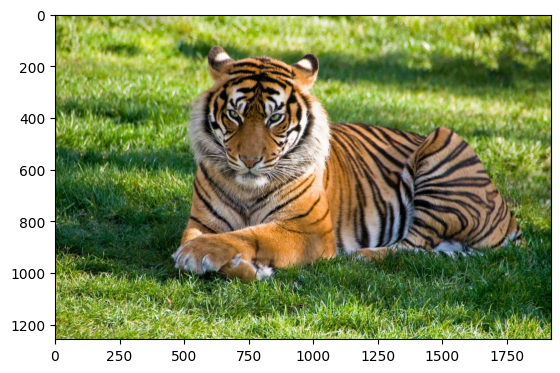

In [2]:
adom.classify_image_with_vgg_weights()

tiger 88.21 %
tiger cat 11.79 %
zebra 0.0 %
jaguar 0.0 %
tabby 0.0 %


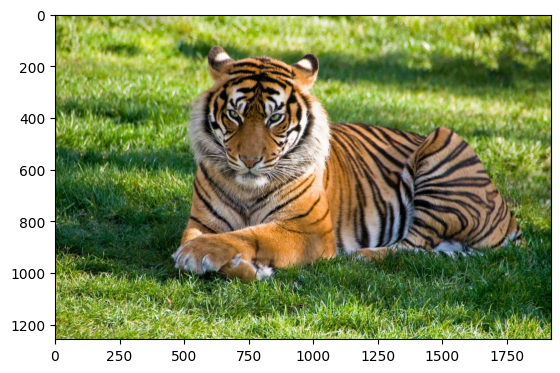

In [3]:
adom.classify_image_with_alexnet_weights()

tiger 56.03 %
tiger cat 21.85 %
zebra 1.19 %
chambered nautilus 0.82 %
monarch 0.43 %


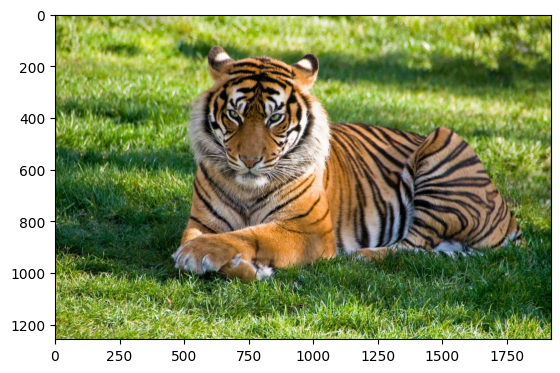

In [3]:
adom.classify_image_with_googlenet_weights()

Klasyfikacja obrazu dla dowolnego modelu

tiger 88.21 %
tiger cat 11.79 %
zebra 0.0 %
jaguar 0.0 %
tabby 0.0 %


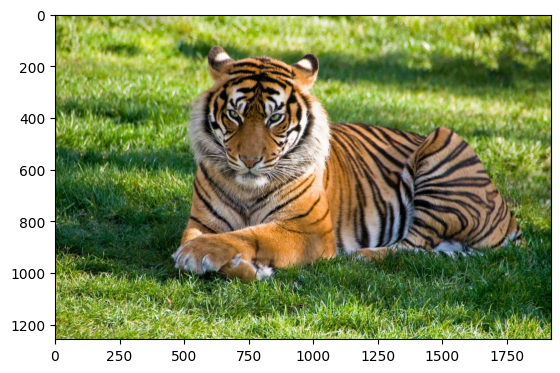

In [2]:
model = models.alexnet(weights = models.AlexNet_Weights.DEFAULT)
classes = models.AlexNet_Weights.DEFAULT.meta["categories"]
adom.classify_image_with_model(model=model, classes=classes)

Trenowanie i klasyfikacja z datasetem

100%|██████████| 170M/170M [01:53<00:00, 1.50MB/s] 


Extracting ./data\cifar-10-python.tar.gz to ./data
Epoch 1, Loss: 1.4120422783184052
Epoch 2, Loss: 0.9222067182159424
Epoch 3, Loss: 0.721226333591938
Epoch 4, Loss: 0.5918282011318207
Epoch 5, Loss: 0.4932225253677368
Epoch 6, Loss: 0.41084545997977256
Epoch 7, Loss: 0.33724312192082406
Epoch 8, Loss: 0.2846028456634283
Epoch 9, Loss: 0.23770323549900205
Epoch 10, Loss: 0.20536955512470564
deer 44.91 %
horse 19.0 %
truck 13.83 %
frog 7.45 %
dog 3.69 %


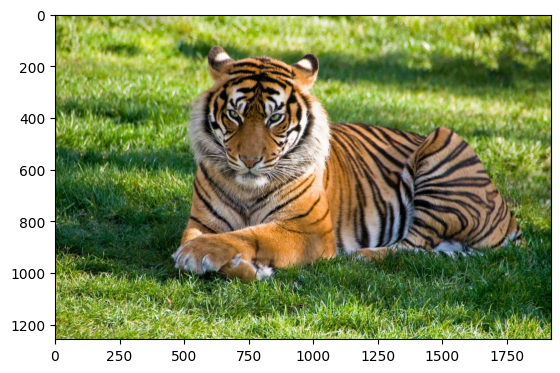

In [2]:
dataset = adom.get_CIFAR10_dataset()
model = adom.train_new_model(dataset)
classes = dataset.classes
adom.classify_image_with_model(model=model, classes=classes)

horse 100.0 %
dog 0.0 %
deer 0.0 %
cat 0.0 %
bird 0.0 %


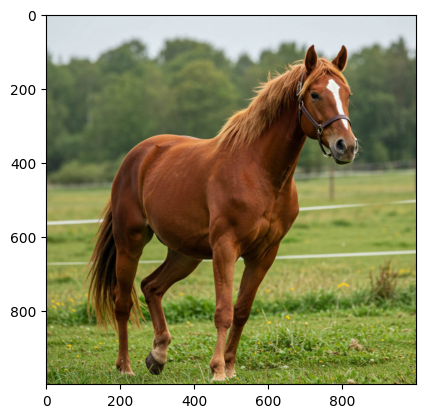

In [3]:
adom.classify_image_with_model(model=model, classes=classes, image_path="kon.jpg")

c:\Users\Sebastian\Desktop\ADOM\ADOM_2026L_Deep_CNN-VGG\adom_library.py:167: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_info = torch.load(models_root + "/" + model_

sorrel 99.09 %
Irish setter 0.36 %
Rhodesian ridgeback 0.32 %
ox 0.06 %
Saluki 0.03 %


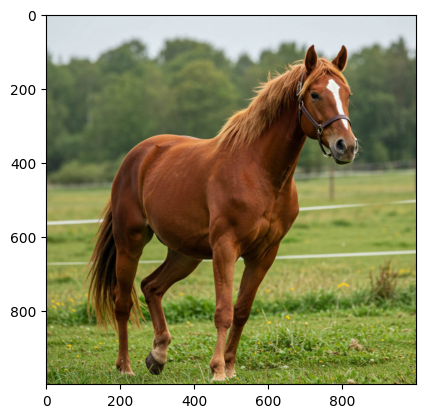

In [2]:
model = models.alexnet(weights = models.AlexNet_Weights.DEFAULT)
classes = models.AlexNet_Weights.DEFAULT.meta["categories"]
adom.save_model(model=model, model_name="alex1", classes=classes)

model, classes = adom.read_model(model_name="alex1", model_type="AlexNet")
adom.classify_image_with_model(model=model, classes=classes, image_path="kon.jpg")

Propozycja eksperymentów:

AlexNet vs VGG16 vs GoogleNet?

(sieci szkieletowe - odmrazanie, douczanie itp)

modyfikacje obrazow, zaklocenia, szukanie slabego punktu

20 minut teoria - 10 min omowienie eksperymentow

Dropout 0.3 vs 0.5 vs brak

Różne optymalizatory - Adam vs SGD

In [ ]:
# zmiana dropout

vgg16.classifier[2] = nn.Dropout(p=0.3)
vgg16.classifier[5] = nn.Dropout(p=0.3)

vgg16.classifier[2] = nn.Identity()
vgg16.classifier[5] = nn.Identity()